In [18]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
import kagglehub
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error,r2_score, mean_squared_error

dataset_path = kagglehub.dataset_download("mikhail1681/walmart-sales")
csv_path = os.path.join(dataset_path, 'Walmart_Sales.csv')

df = pd.read_csv(csv_path)


df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

# Clean Negative Sales (Returns) by capping at 0
df['Weekly_Sales'] = df['Weekly_Sales'].apply(lambda x: max(x, 0))

# Impute missing macroeconomic data (Forward-fill)
df.fillna(method='ffill', inplace=True)

# Isolate Store 1 and sort chronologically
df_store1 = df[df['Store'] == 1].sort_values('Date').set_index('Date')

C:\Users\aksha\AppData\Local\Temp\ipykernel_5040\4165321802.py:24: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='ffill', inplace=True)


In [19]:
df_ml = df_store1.copy()

# Create historical context for the ML models
df_ml['lag_1wk'] = df_ml['Weekly_Sales'].shift(1)
df_ml['lag_2wk'] = df_ml['Weekly_Sales'].shift(2)
df_ml['lag_4wk'] = df_ml['Weekly_Sales'].shift(4)
df_ml['rolling_4wk_avg'] = df_ml['Weekly_Sales'].rolling(window=4).mean()

# Drop rows with NaNs caused by the shift
df_ml.dropna(inplace=True)

# Re-split data to align with the new shifted dataframe
X = df_ml.drop(columns=['Weekly_Sales', 'Store'])
y = df_ml['Weekly_Sales']

X_train, X_test = X.iloc[:train_size-4], X.iloc[train_size-4:]
y_train, y_test = y.iloc[:train_size-4], y.iloc[train_size-4:]


In [20]:
sarima_model = SARIMAX(train['Weekly_Sales'], order=(1, 1, 1), seasonal_order=(1, 1, 0, 52), enforce_stationarity=False, enforce_invertibility=False)
sarima_preds = sarima_model.fit(disp=False).forecast(steps=len(test))
sarima_preds.index = test.index 

lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
lr_preds = lr_model.predict(X_test)


rf_model = RandomForestRegressor(n_estimators=150, max_depth=6, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

gb_model = GradientBoostingRegressor(n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42)
gb_model.fit(X_train, y_train)
gb_preds = gb_model.predict(X_test)

xgb_model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=150, learning_rate=0.05, max_depth=5, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)

c:\Users\aksha\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
c:\Users\aksha\AppData\Local\Programs\Python\Python314\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [21]:
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, r2_score

print("Starting Time-Series Cross-Validation Evaluation...")

# 1. Setup TimeSeriesSplit (5 splits, expanding window)
tscv = TimeSeriesSplit(n_splits=5)

def evaluate_timeseries_model(model_name, model, X_train_full, y_train_full, X_test_full, y_test_full):
    cv_maes = []
    cv_r2s = []
    
    # Run the rolling split purely on the training data
    for train_index, val_index in tscv.split(X_train_full):
        cv_X_train, cv_X_val = X_train_full.iloc[train_index], X_train_full.iloc[val_index]
        cv_y_train, cv_y_val = y_train_full.iloc[train_index], y_train_full.iloc[val_index]
        
        model.fit(cv_X_train, cv_y_train)
        preds = model.predict(cv_X_val)
        
        cv_maes.append(mean_absolute_error(cv_y_val, preds))
        cv_r2s.append(r2_score(cv_y_val, preds))
        
    # Re-train model on the ENTIRE training set for final Test metrics
    model.fit(X_train_full, y_train_full)
    
    # Train Metrics (To check for memorization/overfitting)
    train_preds = model.predict(X_train_full)
    train_mae = mean_absolute_error(y_train_full, train_preds)
    train_r2 = r2_score(y_train_full, train_preds)
    
    # Test Metrics (The unseen Future)
    test_preds = model.predict(X_test_full)
    test_mae = mean_absolute_error(y_test_full, test_preds)
    test_r2 = r2_score(y_test_full, test_preds)
    
    return {
        "Model": model_name,
        "Train MAE": f"${train_mae:,.0f}",
        "CV MAE (5-Fold TS)": f"${np.mean(cv_maes):,.0f}",
        "Test MAE": f"${test_mae:,.0f}",
        "Train R²": f"{train_r2:.3f}",
        "CV R²": f"{np.mean(cv_r2s):,.3f}",
        "Test R²": f"{test_r2:.3f}"
    }

# 2. Compile Results 
ts_results = []

# Using the models you already fitted in Cell 3
models_to_test = {
    "Linear Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model,
    "XGBoost": xgb_model
}

for name, mdl in models_to_test.items():
    ts_results.append(evaluate_timeseries_model(name, mdl, X_train, y_train, X_test, y_test))

# We keep SARIMA's manual test metrics since it doesn't use the ML feature matrix (X_train)
sarima_train_preds = sarima_model.fit(disp=False).predict(start=train.index[0], end=train.index[-1])
ts_results.append({
    "Model": "SARIMA (Baseline)",
    "Train MAE": f"${mean_absolute_error(train['Weekly_Sales'], sarima_train_preds):,.0f}",
    "CV MAE (5-Fold TS)": "N/A", # SARIMA uses statistical AIC/BIC instead of CV
    "Test MAE": f"${mean_absolute_error(y_test, sarima_preds):,.0f}",
    "Train R²": f"{r2_score(train['Weekly_Sales'], sarima_train_preds):.3f}",
    "CV R²": "N/A",
    "Test R²": f"{r2_score(y_test, sarima_preds):.3f}"
})

# 3. Display the final comparison
results_df = pd.DataFrame(ts_results).set_index("Model")

print("\n--- Final Time-Series Model Comparison ---")
display(results_df)

# Store the baseline MAE for your business impact calculation in the next cell
baseline_mae = mean_absolute_error(y_test, sarima_preds)

Starting Time-Series Cross-Validation Evaluation...

--- Final Time-Series Model Comparison ---


,Train MAE,CV MAE (5-Fold TS),Test MAE,Train R²,CV R²,Test R²
Model,,,,,,
Linear Regression,"$77,587","$145,638","$57,309",0.576,-0.623,0.190
Random Forest,"$43,115","$104,624","$107,205",0.887,0.185,-1.418
Gradient Boosting,"$6,247","$109,210","$186,803",0.998,-0.048,-5.748
XGBoost,"$8,339","$101,522","$121,385",0.996,0.125,-1.846
SARIMA (Baseline),"$388,864",N/A,"$72,099",-8.473,N/A,-0.075


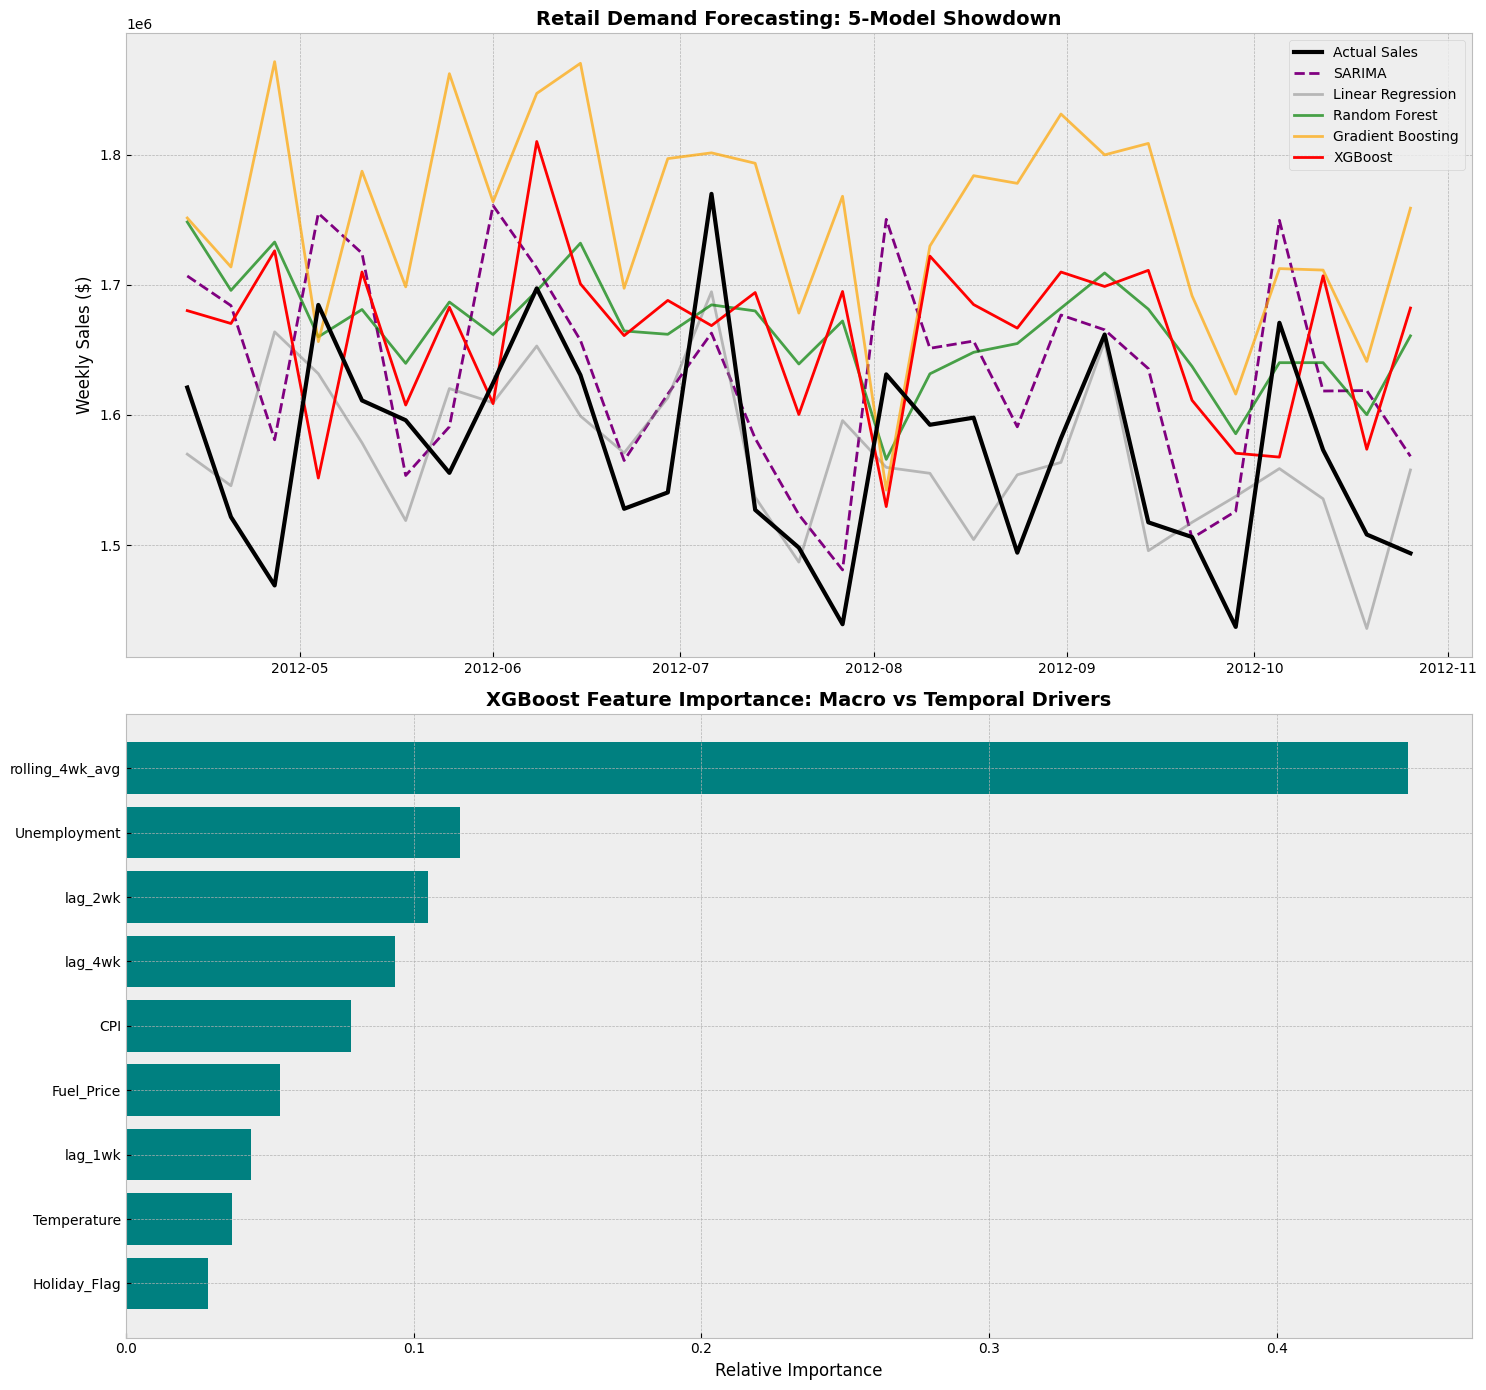

--------------------------------------------------
Actual Average Sales during Peak Weeks: $1,717,201.70

SARIMA          Peak MAE: $64,353.68
Linear Reg      Peak MAE: $57,458.67
Random Forest   Peak MAE: $37,265.53
Grad Boosting   Peak MAE: $69,859.58
XGBoost         Peak MAE: $115,729.52
--------------------------------------------------
Highest actual sales in TRAINING set: $2,387,950.20
Highest actual sales in TESTING set:  $1,769,854.16
Highest predicted sales by XGBoost:   $1,810,111.12
Highest predicted sales by RandForest:$1,748,245.48
--------------------------------------------------
Baseline MAE (SARIMA): $72,099.46 per week

Assuming a $50M/year store. A reduction in error recovers 30% gross margin on stockouts 
and saves 20% holding cost on excess inventory. (Annualized = Weekly Error Savings * 52)

Linear Regression  : +$192,278.63 added to Net Operating Margin/Year
Random Forest      : -$456,374.08 (Performed worse than baseline)
Gradient Boosting  : -$1,491,144.98 (Per

In [23]:
plt.style.use('bmh')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 14))

# Plot 1: 5-Model Showdown
ax1.plot(y_test.index, y_test.values, label='Actual Sales', color='black', linewidth=3, zorder=10)
ax1.plot(y_test.index, sarima_preds, label='SARIMA', linestyle='--', color='purple')
ax1.plot(y_test.index, lr_preds, label='Linear Regression', alpha=0.5, color='gray')
ax1.plot(y_test.index, rf_preds, label='Random Forest', alpha=0.7, color='green')
ax1.plot(y_test.index, gb_preds, label='Gradient Boosting', alpha=0.7, color='orange')
ax1.plot(y_test.index, xgb_preds, label='XGBoost', color='red', linewidth=2, zorder=5)
ax1.set_title('Retail Demand Forecasting: 5-Model Showdown', fontsize=14, fontweight='bold')
ax1.set_ylabel('Weekly Sales ($)')
ax1.legend(loc='upper right')

# Plot 2: Feature Importance from the typically best performing tree model (XGBoost)
importance = xgb_model.feature_importances_
sorted_idx = np.argsort(importance)
ax2.barh(X.columns[sorted_idx], importance[sorted_idx], color='teal')
ax2.set_title('XGBoost Feature Importance: Macro vs Temporal Drivers', fontsize=14, fontweight='bold')
ax2.set_xlabel('Relative Importance')

plt.tight_layout()
plt.show()

# --- Analysis: Peak Holiday Performance ---
print("-" * 50)
peak_indices = y_test.nlargest(3).index
print(f"Actual Average Sales during Peak Weeks: ${y_test[peak_indices].mean():,.2f}\n")

peak_maes = {
    'SARIMA': mean_absolute_error(y_test[peak_indices], sarima_preds.loc[peak_indices]),
    'Linear Reg': mean_absolute_error(y_test[peak_indices], pd.Series(lr_preds, index=y_test.index).loc[peak_indices]),
    'Random Forest': mean_absolute_error(y_test[peak_indices], pd.Series(rf_preds, index=y_test.index).loc[peak_indices]),
    'Grad Boosting': mean_absolute_error(y_test[peak_indices], pd.Series(gb_preds, index=y_test.index).loc[peak_indices]),
    'XGBoost': mean_absolute_error(y_test[peak_indices], pd.Series(xgb_preds, index=y_test.index).loc[peak_indices])
}

for model, mae in peak_maes.items():
    print(f"{model.ljust(15)} Peak MAE: ${mae:,.2f}")

# --- Analysis: Diagnosis of Tree Limitations ---
print("-" * 50)
max_train_val = y_train.max()
print(f"Highest actual sales in TRAINING set: ${max_train_val:,.2f}")
print(f"Highest actual sales in TESTING set:  ${y_test.max():,.2f}")
print(f"Highest predicted sales by XGBoost:   ${xgb_preds.max():,.2f}")
print(f"Highest predicted sales by RandForest:${rf_preds.max():,.2f}")

if y_test.max() > max_train_val:
    print("""
-> DIAGNOSIS: 
   Notice how Random Forest, Gradient Boosting, and XGBoost physically cannot predict a number higher 
   than the historical maximum seen in the training data. If macro-inflation causes a permanent 20% 
   price hike, every tree-based model will fail and chronically under-predict.
""")

# --- Business Impact / Financial Mathematics ---
print("-" * 50)
baseline_mae = mean_absolute_error(y_test, sarima_preds)
print(f"Baseline MAE (SARIMA): ${baseline_mae:,.2f} per week\n")

print("Assuming a $50M/year store. A reduction in error recovers 30% gross margin on stockouts ")
print("and saves 20% holding cost on excess inventory. (Annualized = Weekly Error Savings * 52)\n")

gross_margin = 0.30       
holding_cost_rate = 0.20  

# Dictionary mapping model names to their raw numeric predictions
ml_predictions = {
    'Linear Regression': lr_preds,
    'Random Forest': rf_preds,
    'Gradient Boosting': gb_preds,
    'XGBoost': xgb_preds
}

for model_name, preds in ml_predictions.items():
    
    # Calculate numeric test MAE directly from predictions
    model_mae = mean_absolute_error(y_test, preds)
    
    # Calculate weekly improvement over the baseline
    weekly_savings = baseline_mae - model_mae
    annual_error_reduction = weekly_savings * 52
    
    # Assuming the forecasting error is split evenly (50% over-forecast, 50% under-forecast)
    under_forecast_error = annual_error_reduction * 0.5
    over_forecast_error = annual_error_reduction * 0.5
    
    recovered_profit = under_forecast_error * gross_margin
    saved_holding_costs = over_forecast_error * holding_cost_rate
    total_bottom_line = recovered_profit + saved_holding_costs
    
    if total_bottom_line > 0:
        print(f"{model_name.ljust(18)} : +${total_bottom_line:,.2f} added to Net Operating Margin/Year")
    else:
        print(f"{model_name.ljust(18)} : -${abs(total_bottom_line):,.2f} (Performed worse than baseline)")